In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 1. LOADING THE DATASET

In [16]:
df = pd.read_csv("/content/HistoricalQuotes.csv")

print("First 5 rows:")
print(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

First 5 rows:
         Date     Close     Volume      Open      High       Low
0  02/28/2020   $273.36  106721200   $257.26   $278.41   $256.37
1  02/27/2020   $273.52   80151380    $281.1      $286   $272.96
2  02/26/2020   $292.65   49678430   $286.53   $297.88    $286.5
3  02/25/2020   $288.08   57668360   $300.95   $302.53   $286.13
4  02/24/2020   $298.18   55548830   $297.26   $304.18   $289.23

Column names:
['Date', 'Close', 'Volume', 'Open', 'High', 'Low']

Dataset shape:
(2518, 6)


### 2. PREPROCESSING

In [17]:
# a. Strip “$” from price columns and convert datatype to float. (2 marks)

price_cols = ["Open", "High", "Low", "Close"]
for col in price_cols:
    df[col] = df[col].astype(str).str.replace("$", "", regex=False)
    df[col] = df[col].str.replace(",", "", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()

,Date,Close,Volume,Open,High,Low
0,02/28/2020,273.36,106721200,257.26,278.41,256.37
1,02/27/2020,273.52,80151380,281.10,286.00,272.96
2,02/26/2020,292.65,49678430,286.53,297.88,286.50
3,02/25/2020,288.08,57668360,300.95,302.53,286.13
4,02/24/2020,298.18,55548830,297.26,304.18,289.23


In [18]:
# b. Fix mixed date formats (MM/DD/YYYY and MM-DD-YYYY), to DD/MM/YYYY format and perform linear interpolation of the missing dates. (2 marks)

if df.index.name == 'Date':
    df = df.reset_index()

df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df = df.sort_values(by='Date')

df = df.groupby('Date').mean(numeric_only=True).reset_index()

df = df.set_index('Date')
df = df.resample('D').asfreq()
df = df.interpolate(method='time')
df = df.reset_index()
df['Date'] = df['Date'].dt.strftime('%d/%m/%Y')
df.head()

,Date,Close,Volume,Open,High,Low
0,01/03/2010,29.8557,137312041.0,29.3928,29.9286,29.3500
1,02/03/2010,29.8357,141486282.0,29.9900,30.1186,29.6771
2,03/03/2010,29.9043,92846488.0,29.8486,29.9814,29.7057
3,04/03/2010,30.1014,89591907.0,29.8971,30.1314,29.8043
4,05/03/2010,31.2786,224647427.0,30.7057,31.3857,30.6614


### 3. DATA PREPARATION

In [25]:
# a. Split into train/val/test (70-15-15) chronologically and scale the data and fit only on train set. (1 marks)
X = df.drop(['Close', 'Date'], axis=1)
y = df['Close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, shuffle=False)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [20]:
# b. Take seq_len = 15 and construct the respective sequences and load the data using Data Loaders. (2 marks)
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

seq_len = 15
class SequenceDataset(Dataset):
    def __init__(self, data, seq_len):
        self.sequences = []
        clean_data = data[~np.isnan(data)]
        for i in range(len(clean_data) - seq_len):
            x = clean_data[i : i + seq_len]
            y = clean_data[i + seq_len]
            self.sequences.append((
                torch.tensor(x, dtype=torch.float32).unsqueeze(-1),
                torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
            ))

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]


y_train_clean = y_train.dropna().values
y_val_clean = y_val.dropna().values
y_test_clean = y_test.dropna().values

train_dataset = SequenceDataset(y_train_clean, seq_len)
val_dataset = SequenceDataset(y_val_clean, seq_len)
test_dataset = SequenceDataset(y_test_clean, seq_len)

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### 4. STACKED RNN

In [21]:
# a.Implement a RNN cell from scratch, and using it stack 2 of them
import torch
import torch.nn as nn
import math

class myRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.W_xh = nn.Parameter(torch.Tensor(hidden_size, input_size))
        self.W_hh = nn.Parameter(torch.Tensor(hidden_size, hidden_size))
        self.b_ih = nn.Parameter(torch.Tensor(hidden_size))
        self.b_hh = nn.Parameter(torch.Tensor(hidden_size))
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1.0 / math.sqrt(self.hidden_size)
        for weight in self.parameters():
            nn.init.uniform_(weight, -stdv, stdv)

    def forward(self, x, h_prev):
        out = torch.matmul(x, self.W_xh.t()) + self.b_ih + torch.matmul(h_prev, self.W_hh.t()) + self.b_hh
        return torch.tanh(out)

class StackedRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.layers = nn.ModuleList()
        self.layers.append(myRNNCell(input_size, hidden_size))
        for _ in range(1, num_layers):
            self.layers.append(myRNNCell(hidden_size, hidden_size))
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x, h_0=None):
        batch_size, seq_len, _ = x.size()
        if h_0 is None:
            h_0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        h_prev_layers = list(torch.unbind(h_0, dim=0))
        outputs = []
        for t in range(seq_len):
            current_input = x[:, t, :]
            for layer_idx in range(self.num_layers):
                h_next = self.layers[layer_idx](current_input, h_prev_layers[layer_idx])
                h_prev_layers[layer_idx] = h_next
                current_input = h_next

            outputs.append(current_input.unsqueeze(1))

        out_sequence = torch.cat(outputs, dim=1)

        final_output = self.fc(out_sequence[:, -1, :])
        final_output = self.relu(final_output)

        h_n = torch.stack(h_prev_layers, dim=0)
        return final_output, h_n

Starting training...
Epoch [1/20], Train Loss: 0.0208, Val Loss: 0.0235
Epoch [2/20], Train Loss: 0.0003, Val Loss: 0.0199
Epoch [3/20], Train Loss: 0.0003, Val Loss: 0.0106
Epoch [4/20], Train Loss: 0.0003, Val Loss: 0.0110
Epoch [5/20], Train Loss: 0.0003, Val Loss: 0.0084
Epoch [6/20], Train Loss: 0.0003, Val Loss: 0.0073
Epoch [7/20], Train Loss: 0.0002, Val Loss: 0.0054
Epoch [8/20], Train Loss: 0.0002, Val Loss: 0.0073
Epoch [9/20], Train Loss: 0.0002, Val Loss: 0.0057
Epoch [10/20], Train Loss: 0.0002, Val Loss: 0.0055
Epoch [11/20], Train Loss: 0.0002, Val Loss: 0.0066
Epoch [12/20], Train Loss: 0.0002, Val Loss: 0.0043
Epoch [13/20], Train Loss: 0.0002, Val Loss: 0.0012
Epoch [14/20], Train Loss: 0.0002, Val Loss: 0.0043
Epoch [15/20], Train Loss: 0.0002, Val Loss: 0.0021
Epoch [16/20], Train Loss: 0.0002, Val Loss: 0.0019
Epoch [17/20], Train Loss: 0.0002, Val Loss: 0.0014
Epoch [18/20], Train Loss: 0.0002, Val Loss: 0.0015
Epoch [19/20], Train Loss: 0.0002, Val Loss: 0.0009


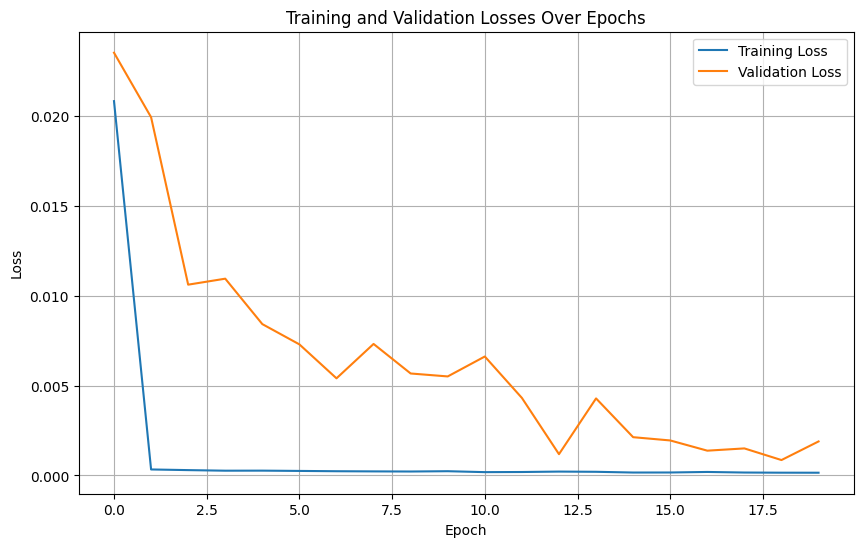


Test Set Evaluation:
Mean Squared Error (MSE): 369.5695
R-squared (R2) Score: 0.8259


In [28]:
# hidden_size = 64, batch_size = 32, lr = 0.001. adam optimizer, mse loss, 20 epochs
# b. Train the model for 20 epochs
# c. Plot the training and validation losses
# d. Evaluate on the test set and report R2 and MSE scores

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import numpy as np

seq_len = globals().get('seq_len', 15)
y_train_clean = globals().get('y_train_clean', np.array([]))
y_val_clean = globals().get('y_val_clean', np.array([]))
y_test_clean = globals().get('y_test_clean', np.array([]))

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_clean.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val_clean.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test_clean.reshape(-1, 1)).flatten()

train_dataset = SequenceDataset(y_train_scaled, seq_len)
val_dataset = SequenceDataset(y_val_scaled, seq_len)
test_dataset = SequenceDataset(y_test_scaled, seq_len)

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
model = StackedRNN(input_size=1, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for inputs, targets in train_dataloader:
        optimizer.zero_grad()
        outputs, _ = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_train_loss / len(train_dataloader.dataset)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            outputs, _ = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)

    avg_val_loss = running_val_loss / len(val_dataloader.dataset)
    val_losses.append(avg_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

print("Training complete.")

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_dataloader:
        outputs, _ = model(inputs)
        all_predictions.extend(outputs.squeeze().cpu().numpy())
        all_targets.extend(targets.squeeze().cpu().numpy())

all_predictions = np.array(all_predictions)
all_targets = np.array(all_targets)

all_predictions_original_scale = y_scaler.inverse_transform(all_predictions.reshape(-1, 1)).flatten()
all_targets_original_scale = y_scaler.inverse_transform(all_targets.reshape(-1, 1)).flatten()

mse = mean_squared_error(all_targets_original_scale, all_predictions_original_scale)
r2 = r2_score(all_targets_original_scale, all_predictions_original_scale)

print(f'\nTest Set Evaluation:')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'R-squared (R2) Score: {r2:.4f}')

### 5. BIDIRECTIONAL RNN

Starting Bi-RNN training...
Epoch [1/20], Train Loss: 0.0147, Val Loss: 0.0089
Epoch [2/20], Train Loss: 0.0005, Val Loss: 0.0096
Epoch [3/20], Train Loss: 0.0004, Val Loss: 0.0087
Epoch [4/20], Train Loss: 0.0004, Val Loss: 0.0100
Epoch [5/20], Train Loss: 0.0004, Val Loss: 0.0074
Epoch [6/20], Train Loss: 0.0003, Val Loss: 0.0089
Epoch [7/20], Train Loss: 0.0003, Val Loss: 0.0049
Epoch [8/20], Train Loss: 0.0003, Val Loss: 0.0071
Epoch [9/20], Train Loss: 0.0004, Val Loss: 0.0047
Epoch [10/20], Train Loss: 0.0003, Val Loss: 0.0054
Epoch [11/20], Train Loss: 0.0002, Val Loss: 0.0026
Epoch [12/20], Train Loss: 0.0002, Val Loss: 0.0033
Epoch [13/20], Train Loss: 0.0002, Val Loss: 0.0038
Epoch [14/20], Train Loss: 0.0002, Val Loss: 0.0019
Epoch [15/20], Train Loss: 0.0002, Val Loss: 0.0023
Epoch [16/20], Train Loss: 0.0002, Val Loss: 0.0015
Epoch [17/20], Train Loss: 0.0002, Val Loss: 0.0009
Epoch [18/20], Train Loss: 0.0002, Val Loss: 0.0014
Epoch [19/20], Train Loss: 0.0002, Val Loss: 

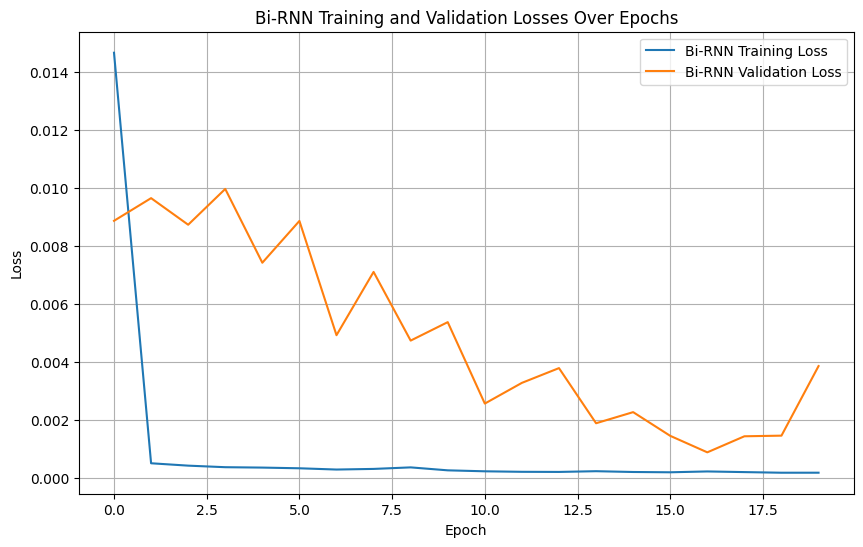


Bi-RNN Test Set Evaluation:
Mean Squared Error (MSE): 470.9439
R-squared (R2) Score: 0.7781


In [31]:
# a.Implement a Bi-RNN using the same RNN cell (forward + backward, concatenated),and use the same parameters as before. (10 marks)
# b. Train the model for 20 epochs. (2 marks)
# c. Plot the training and validation losses. (1 marks)
# d. Evaluate on the test set and report R2 and MSE scores

import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader

class BiRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.forward_layers = nn.ModuleList()
        self.forward_layers.append(myRNNCell(input_size, hidden_size))
        for _ in range(1, num_layers):
            self.forward_layers.append(myRNNCell(hidden_size, hidden_size))

        self.backward_layers = nn.ModuleList()
        self.backward_layers.append(myRNNCell(input_size, hidden_size))
        for _ in range(1, num_layers):
            self.backward_layers.append(myRNNCell(hidden_size, hidden_size))

        self.fc = nn.Linear(2 * hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x, h_0_forward=None, h_0_backward=None):
        batch_size, seq_len, _ = x.size()

        if h_0_forward is None:
            h_0_forward = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)
        if h_0_backward is None:
            h_0_backward = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=x.device)

        final_h_forward_last_layer = None
        current_h_forward_layers = list(torch.unbind(h_0_forward, dim=0))
        for t in range(seq_len):
            current_input_t = x[:, t, :]
            for layer_idx in range(self.num_layers):
                h_next = self.forward_layers[layer_idx](current_input_t, current_h_forward_layers[layer_idx])
                current_h_forward_layers[layer_idx] = h_next
                current_input_t = h_next
            if t == seq_len - 1:
                final_h_forward_last_layer = current_input_t

        x_reversed = torch.flip(x, [1])
        final_h_backward_last_layer = None
        current_h_backward_layers = list(torch.unbind(h_0_backward, dim=0))
        for t in range(seq_len):
            current_input_t = x_reversed[:, t, :]
            for layer_idx in range(self.num_layers):
                h_next = self.backward_layers[layer_idx](current_input_t, current_h_backward_layers[layer_idx])
                current_h_backward_layers[layer_idx] = h_next
                current_input_t = h_next
            if t == seq_len - 1:
                final_h_backward_last_layer = current_input_t

        combined_output = torch.cat((final_h_forward_last_layer, final_h_backward_last_layer), dim=1)

        final_output = self.fc(combined_output)
        final_output = self.relu(final_output)

        h_n_forward = torch.stack(current_h_forward_layers, dim=0)
        h_n_backward = torch.stack(current_h_backward_layers, dim=0)
        h_n = torch.cat((h_n_forward, h_n_backward), dim=0)

        return final_output, h_n

seq_len = globals().get('seq_len', 15)
y_train_clean = globals().get('y_train_clean', np.array([]))
y_val_clean = globals().get('y_val_clean', np.array([]))
y_test_clean = globals().get('y_test_clean', np.array([]))

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_clean.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val_clean.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test_clean.reshape(-1, 1)).flatten()

train_dataset = SequenceDataset(y_train_scaled, seq_len)
val_dataset = SequenceDataset(y_val_scaled, seq_len)
test_dataset = SequenceDataset(y_test_scaled, seq_len)

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
model = StackedRNN(input_size=1, hidden_size=64, num_layers=2, output_size=1)

model_bi = BiRNN(input_size=1, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer_bi = torch.optim.Adam(model_bi.parameters(), lr=0.001)

num_epochs = 20
train_losses_bi = []
val_losses_bi = []

print("Starting Bi-RNN training...")
for epoch in range(num_epochs):
    model_bi.train()
    running_train_loss = 0.0
    for inputs, targets in train_dataloader:
        optimizer_bi.zero_grad()
        outputs, _ = model_bi(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_bi.step()
        running_train_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_train_loss / len(train_dataloader.dataset)
    train_losses_bi.append(avg_train_loss)

    model_bi.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            outputs, _ = model_bi(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)

    avg_val_loss = running_val_loss / len(val_dataloader.dataset)
    val_losses_bi.append(avg_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

print("Bi-RNN training complete.")

plt.figure(figsize=(10, 6))
plt.plot(train_losses_bi, label='Bi-RNN Training Loss')
plt.plot(val_losses_bi, label='Bi-RNN Validation Loss')
plt.title('Bi-RNN Training and Validation Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

model_bi.eval()
all_predictions_bi = []
all_targets_bi = []

with torch.no_grad():
    for inputs, targets in test_dataloader:
        outputs, _ = model_bi(inputs)
        all_predictions_bi.extend(outputs.squeeze().cpu().numpy())
        all_targets_bi.extend(targets.squeeze().cpu().numpy())

all_predictions_bi = np.array(all_predictions_bi)
all_targets_bi = np.array(all_targets_bi)

all_predictions_bi_original_scale = y_scaler.inverse_transform(all_predictions_bi.reshape(-1, 1)).flatten()
all_targets_bi_original_scale = y_scaler.inverse_transform(all_targets_bi.reshape(-1, 1)).flatten()

mse_bi = mean_squared_error(all_targets_bi_original_scale, all_predictions_bi_original_scale)
r2_bi = r2_score(all_targets_bi_original_scale, all_predictions_bi_original_scale)

print(f'\nBi-RNN Test Set Evaluation:')
print(f'Mean Squared Error (MSE): {mse_bi:.4f}')
print(f'R-squared (R2) Score: {r2_bi:.4f}')

### 6. ATTENTION-BASED RNN

Starting Attention-RNN training...
Epoch [1/20], Train Loss: 0.0155, Val Loss: 0.0198
Epoch [2/20], Train Loss: 0.0009, Val Loss: 0.0290
Epoch [3/20], Train Loss: 0.0008, Val Loss: 0.0225
Epoch [4/20], Train Loss: 0.0007, Val Loss: 0.0179
Epoch [5/20], Train Loss: 0.0008, Val Loss: 0.0213
Epoch [6/20], Train Loss: 0.0007, Val Loss: 0.0184
Epoch [7/20], Train Loss: 0.0007, Val Loss: 0.0142
Epoch [8/20], Train Loss: 0.0008, Val Loss: 0.0138
Epoch [9/20], Train Loss: 0.0006, Val Loss: 0.0129
Epoch [10/20], Train Loss: 0.0005, Val Loss: 0.0062
Epoch [11/20], Train Loss: 0.0005, Val Loss: 0.0047
Epoch [12/20], Train Loss: 0.0004, Val Loss: 0.0039
Epoch [13/20], Train Loss: 0.0004, Val Loss: 0.0050
Epoch [14/20], Train Loss: 0.0003, Val Loss: 0.0042
Epoch [15/20], Train Loss: 0.0004, Val Loss: 0.0066
Epoch [16/20], Train Loss: 0.0004, Val Loss: 0.0050
Epoch [17/20], Train Loss: 0.0003, Val Loss: 0.0041
Epoch [18/20], Train Loss: 0.0004, Val Loss: 0.0042
Epoch [19/20], Train Loss: 0.0003, Val

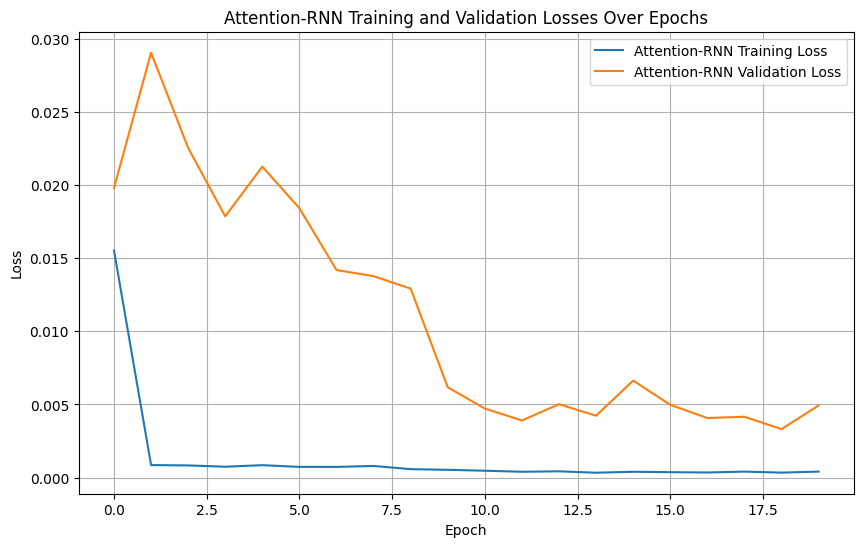


Attention-RNN Test Set Evaluation:
Mean Squared Error (MSE): 552.9089
R-squared (R2) Score: 0.7395


In [32]:
# Implement an RNN with an attention layer that scores odd and even timesteps using two separate learned vectors, softmax over the sequence, weighted sum as context. For this question, you may directly use nn.RNN. Use the same parameters as before

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

class AttentionRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.attn_even_vec = nn.Parameter(torch.randn(hidden_size))
        self.attn_odd_vec = nn.Parameter(torch.randn(hidden_size))
        self.fc = nn.Linear(hidden_size, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        output, h_n = self.rnn(x)
        batch_size, seq_len, hidden_size = output.size()
        scores = torch.zeros(batch_size, seq_len, device=x.device)
        for t in range(seq_len):
            hidden_state_t = output[:, t, :]
            if t % 2 == 0:
                scores[:, t] = torch.matmul(hidden_state_t, self.attn_even_vec)
            else:
                scores[:, t] = torch.matmul(hidden_state_t, self.attn_odd_vec)

        attn_weights = F.softmax(scores, dim=1)
        context_vector = torch.bmm(attn_weights.unsqueeze(1), output).squeeze(1)

        final_output = self.fc(context_vector)
        final_output = self.relu(final_output)

        return final_output, h_n

seq_len = globals().get('seq_len', 15)
y_train_clean = globals().get('y_train_clean', np.array([]))
y_val_clean = globals().get('y_val_clean', np.array([]))
y_test_clean = globals().get('y_test_clean', np.array([]))

y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train_clean.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val_clean.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test_clean.reshape(-1, 1)).flatten()

train_dataset = SequenceDataset(y_train_scaled, seq_len)
val_dataset = SequenceDataset(y_val_scaled, seq_len)
test_dataset = SequenceDataset(y_test_scaled, seq_len)

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
model = StackedRNN(input_size=1, hidden_size=64, num_layers=2, output_size=1)

model_attn = AttentionRNN(input_size=1, hidden_size=64, num_layers=2, output_size=1)
criterion = nn.MSELoss()
optimizer_attn = torch.optim.Adam(model_attn.parameters(), lr=0.001)

num_epochs = 20
train_losses_attn = []
val_losses_attn = []

print("Starting Attention-RNN training...")
for epoch in range(num_epochs):
    model_attn.train()
    running_train_loss = 0.0
    for inputs, targets in train_dataloader:
        optimizer_attn.zero_grad()
        outputs, _ = model_attn(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer_attn.step()
        running_train_loss += loss.item() * inputs.size(0)

    avg_train_loss = running_train_loss / len(train_dataloader.dataset)
    train_losses_attn.append(avg_train_loss)
    model_attn.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            outputs, _ = model_attn(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)

    avg_val_loss = running_val_loss / len(val_dataloader.dataset)
    val_losses_attn.append(avg_val_loss)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')

print("Attention-RNN training complete.")

plt.figure(figsize=(10, 6))
plt.plot(train_losses_attn, label='Attention-RNN Training Loss')
plt.plot(val_losses_attn, label='Attention-RNN Validation Loss')
plt.title('Attention-RNN Training and Validation Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

model_attn.eval()
all_predictions_attn = []
all_targets_attn = []

with torch.no_grad():
    for inputs, targets in test_dataloader:
        outputs, _ = model_attn(inputs)
        all_predictions_attn.extend(outputs.squeeze().cpu().numpy())
        all_targets_attn.extend(targets.squeeze().cpu().numpy())

all_predictions_attn = np.array(all_predictions_attn)
all_targets_attn = np.array(all_targets_attn)

all_predictions_attn_original_scale = y_scaler.inverse_transform(all_predictions_attn.reshape(-1, 1)).flatten()
all_targets_attn_original_scale = y_scaler.inverse_transform(all_targets_attn.reshape(-1, 1)).flatten()

mse_attn = mean_squared_error(all_targets_attn_original_scale, all_predictions_attn_original_scale)
r2_attn = r2_score(all_targets_attn_original_scale, all_predictions_attn_original_scale)

print(f'\nAttention-RNN Test Set Evaluation:')
print(f'Mean Squared Error (MSE): {mse_attn:.4f}')
print(f'R-squared (R2) Score: {r2_attn:.4f}')